In [ ]:
!pip install trl[vllm] --quiet
!wandb disabled

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 156.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig
from trl import GRPOConfig, GRPOTrainer, SFTConfig, SFTTrainer
from vllm import LLM

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

import os
save_path = "/content/drive/My Drive/Colab Notebooks/Deep RL/"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

Mounted at /content/drive/


'cuda'

## Dataset

In [ ]:
dataset = load_dataset("openai/gsm8k", 'main')

import regex as re

def preprocess_gsm8k(example):
    parts = example['answer'].split('####')
    thought_content = parts[0].strip()
    final_answer = parts[1].strip()

    thought_content = re.sub(r'<<.*?>>', '', thought_content)

    formatted_text = (
        f"Question: {example['question']}\n"
        f"<think>\n{thought_content}\n</think>\n"
        f"<answer>{final_answer}</answer>"
    )

    return {"text": formatted_text}


train_dataset = dataset['train'].map(preprocess_gsm8k)
test_dataset = dataset['test'].map(preprocess_gsm8k)



README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

# Base model

In [ ]:
checkpoint = "HuggingFaceTB/SmolLM2-360M"
model = AutoModelForCausalLM.from_pretrained(checkpoint).to(device)

tokenizer = AutoTokenizer.from_pretrained(checkpoint)
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

In [ ]:
model.save_pretrained(save_path + "smollm2-base")
tokenizer.save_pretrained(save_path + "smollm2-base")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-base/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-base/tokenizer.json')

# SFT SmolLM2-360M on GSM8K

In [ ]:
train_dataset[0]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72',
 'text': 'Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?\n<think>\nNatalia sold 48/2 = 24 clips in May.\nNatalia sold 48+24 = 72 clips altogether in April and May.\n</think>\n<answer>72</answer>'}

In [ ]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

sft_config = SFTConfig(
    output_dir=save_path + "/smollm2-sft-gsm8k",
    max_length=512,
    dataset_text_field="text",
    per_device_train_batch_size=32,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=10,
    bf16 = True
)

In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    peft_config=peft_config,
    args=sft_config,
)

trainer.train()

merged_model = trainer.model.merge_and_unload()
merged_model.save_pretrained(save_path + "smollm2-sft-gsm8k")
tokenizer.save_pretrained(save_path + "smollm2-sft-gsm8k")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
10,1.569700
20,1.428500
30,1.334500
40,1.254000
50,1.207800


wandb: WARNING URL not available in offline run


('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-sft-gsm8k/tokenizer.json')

# GRPO Training

In [ ]:
def chat(current_model, question):
    prompt = f"Question: {question}\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = current_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        top_p=0.9,
        temperature=0.2,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    input_length = inputs.input_ids.shape[-1]
    response = tokenizer.decode(output[0][input_length:], skip_special_tokens=True)

    return response

In [ ]:
sft_model = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-sft-gsm8k",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

tokenizer = AutoTokenizer.from_pretrained(
    save_path + "smollm2-sft-gsm8k",
    local_files_only=True
)

In [ ]:
math_question = "John has 5 apples. He buys 3 more from the store, and then gives 2 to his friend. How many apples does John have left?"
print(chat(sft_model, math_question))

<think>
John has 5 apples. He buys 3 more apples from the store. That's 8 apples.
He gives 2 apples to his friend. That's 6 apples.
John has 8 + 6 = 14 apples.
</think>
<answer>14</answer>


In [ ]:
def format_for_grpo(example):
    parts = example['answer'].split('####')
    return {
        "prompt": f"Question: {example['question']}\n<think>\n",
        "answer": parts[1].strip()
    }

grpo_dataset = dataset['train'].map(format_for_grpo, remove_columns=dataset['train'].column_names)

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

In [ ]:
grpo_dataset[0]

{'answer': '72',
 'prompt': 'Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?\n<think>\n'}

### GRPO Reward functions

R1: Baseline \
Rewards gets one point (+1) if predicted answer matches correct answer (gold)

R2: Format + Outcome \
Splits the reward into three parts. 0.2 for having <think> tags, 0.2 for having <answer> tags, and 0.6 for the answer being correct. The idea is to explicitly reward the model for following the XML format, not just getting the right answer.

R3: Reasoning Aware \
Tries to reward the quality of the thinking, not just the format. It looks inside <think> and counts arithmetic expressions like 5 + 9 or 12 × 3 using regex. Each detected step adds 0.05 to the score up to a max of 0.3, then 0.7 for correctness. The intuition is to push the model toward showing actual calculation steps rather than just stating an answer.

R4: Efficiency Regularized \
Rewards correctness (0.8) but subtracts a penalty based on how long the completion is. Completions under 150 characters get no penalty, anything longer gets penalized proportionally. The goal is to discourage the model from generating verbose or repetitive reasoning and instead produce concise solutions.

In [ ]:
def reward_r1(completions, prompts, **kwargs):
    answers = kwargs.get('answer', [])
    rewards = []
    for completion, answer in zip(completions, answers):
        match = re.search(r'<answer>(.*?)</answer>', completion, re.DOTALL)
        predicted = match.group(1).strip() if match else ""
        rewards.append(1.0 if predicted == answer else 0.0)
    return rewards

def reward_r2(completions, prompts, **kwargs):
    answers = kwargs.get('answer', [])
    rewards = []
    for completion, answer in zip(completions, answers):
        score = 0.0
        if re.search(r'<think>.*?</think>', completion, re.DOTALL):
            score += 0.2
        if re.search(r'<answer>.*?</answer>', completion, re.DOTALL):
            score += 0.2
        match = re.search(r'<answer>(.*?)</answer>', completion, re.DOTALL)
        if match and match.group(1).strip() == answer.strip():
            score += 0.6
        rewards.append(score)
    return rewards

def reward_r3(completions, prompts, **kwargs):
    rewards = []
    answers = kwargs['answer']  # list of gold answers
    for completion, gold in zip(completions, answers):
        score = 0.0
        think_match = re.search(r'<think>(.*?)</think>', completion, re.DOTALL)
        if think_match:
            thought = think_match.group(1)
            num_steps = len(re.findall(r'\d+\s*[\+\-\*\/]\s*\d+', thought))
            score += min(0.3, num_steps * 0.05)
        match = re.search(r'<answer>(.*?)</answer>', completion, re.DOTALL)
        if match and match.group(1).strip() == gold.strip():
            score += 0.7
        rewards.append(score)
    return rewards

def reward_r4(completions, prompts, **kwargs):
    rewards = []
    answers = kwargs['answer']
    for completion, gold in zip(completions, answers):
        match = re.search(r'<answer>(.*?)</answer>', completion, re.DOTALL)
        correct = match and match.group(1).strip() == gold.strip()
        length_penalty = max(0, (len(completion) - 150) / 500)
        rewards.append(max(0.0, (0.8 if correct else 0.0) - length_penalty))
    return rewards

GRPOConfig

In [ ]:
import sys
import os

# Forcefully patch sys.stdout.fileno to avoid UnsupportedOperation in Colab
sys.stdout.fileno = lambda: os.open(os.devnull, os.O_WRONLY)

grpo_config = GRPOConfig(
    output_dir=save_path + "./smollm2-grpo-r1",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    num_generations=4,
    max_completion_length=512,
    bf16=True,
    logging_steps=10,
    gradient_checkpointing=True,
    use_vllm=True,
    vllm_gpu_memory_utilization=0.3
)

GRPO R1

In [ ]:
grpo_trainer = GRPOTrainer(
    model=sft_model,
    reward_funcs=reward_r1,
    args=grpo_config,
    train_dataset=grpo_dataset
)

grpo_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 19/19 [00:00<00:00, 19.22it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 11/11 [00:00<00:00, 22.44it/s]
wandb: Loading settings from /content/wandb/settings
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.003200
20,0.001900
30,0.009500
40,0.007400
50,0.005100
60,0.007300
70,0.001400
80,-0.003700
90,-0.000800
100,0.002100


TrainOutput(global_step=467, training_loss=0.0033555827163383204, metrics={'train_runtime': 1807.4899, 'train_samples_per_second': 4.134, 'train_steps_per_second': 0.258, 'total_flos': 0.0, 'train_loss': 0.0033555827163383204})

In [ ]:
grpo_trainer.save_model(save_path + "smollm2-grpo-r1")
tokenizer.save_pretrained(save_path + "smollm2-grpo-r1")

('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r1/tokenizer.json')

GRPO R2

In [ ]:
grpo_trainer = GRPOTrainer(
    model=sft_model,
    reward_funcs=reward_r2,
    args=grpo_config,
    train_dataset=grpo_dataset
)

grpo_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 19/19 [00:00<00:00, 19.30it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 11/11 [00:00<00:00, 21.66it/s]
wandb: Loading settings from /content/wandb/settings
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.034400
20,0.050500
30,0.028300
40,0.029100
50,0.068600
60,0.045500
70,0.069900
80,0.029000
90,-0.001800
100,-0.001900


TrainOutput(global_step=467, training_loss=0.036993862099833866, metrics={'train_runtime': 1829.1098, 'train_samples_per_second': 4.086, 'train_steps_per_second': 0.255, 'total_flos': 0.0, 'train_loss': 0.036993862099833866})

In [ ]:
grpo_trainer.save_model(save_path + "smollm2-grpo-r2")
tokenizer.save_pretrained(save_path + "smollm2-grpo-r2")

('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r2/tokenizer.json')

GRPO R3

In [ ]:
grpo_trainer = GRPOTrainer(
    model=sft_model,
    reward_funcs=reward_r3,
    args=grpo_config,
    train_dataset=grpo_dataset
)

grpo_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 19/19 [00:00<00:00, 21.25it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 11/11 [00:00<00:00, 23.33it/s]
wandb: Loading settings from /content/wandb/settings
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.005600
20,-0.002700
30,-0.000200
40,-0.001200
50,0.000100
60,-0.000500
70,-0.005600
80,-0.000100
90,0.008200
100,0.002300


TrainOutput(global_step=467, training_loss=0.001637858218998036, metrics={'train_runtime': 1785.3098, 'train_samples_per_second': 4.186, 'train_steps_per_second': 0.262, 'total_flos': 0.0, 'train_loss': 0.001637858218998036})

In [ ]:
grpo_trainer.save_model(save_path + "smollm2-grpo-r3")
tokenizer.save_pretrained(save_path + "smollm2-grpo-r3")

('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r3/tokenizer.json')

GRPO R4

In [ ]:
grpo_trainer = GRPOTrainer(
    model=sft_model,
    reward_funcs=reward_r4,
    args=grpo_config,
    train_dataset=grpo_dataset
)

grpo_trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 19/19 [00:00<00:00, 20.12it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 11/11 [00:00<00:00, 19.55it/s]
wandb: Loading settings from /content/wandb/settings
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.011800
20,0.008400
30,0.002700
40,0.004500
50,0.000200
60,0.009800
70,0.007300
80,0.009200
90,0.008200
100,0.000900


TrainOutput(global_step=467, training_loss=0.004101070519078052, metrics={'train_runtime': 1784.0158, 'train_samples_per_second': 4.189, 'train_steps_per_second': 0.262, 'total_flos': 0.0, 'train_loss': 0.004101070519078052})

In [ ]:
grpo_trainer.save_model(save_path + "smollm2-grpo-r4")
tokenizer.save_pretrained(save_path + "smollm2-grpo-r4")

('/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/Deep RL/smollm2-grpo-r4/tokenizer.json')

## Evaluating

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-base",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
sft_model = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-sft-gsm8k",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

tokenizer = AutoTokenizer.from_pretrained(
    save_path + "smollm2-sft-gsm8k",
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
grpo_model_r1 = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-grpo-r1",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
grpo_model_r2 = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-grpo-r2",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
grpo_model_r3 = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-grpo-r3",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
grpo_model_r4 = AutoModelForCausalLM.from_pretrained(
    save_path + "smollm2-grpo-r4",
    device_map="auto",
    dtype=torch.bfloat16,
    local_files_only=True
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate(model, dataset, model_name, n=600):
    correct = 0
    format_correct = 0
    lengths = []
    think_lengths = []

    print(f"\n--- Qualitative Sample for {model_name} ---")
    for i, example in enumerate(tqdm(dataset.select(range(n)), desc=f"Evaluating {model_name}")):
        response = chat(model, example['question'])
        gold = example['answer'].split('####')[1].strip()

        # Accuracy
        match = re.search(r'<answer>(.*?)</answer>', response, re.DOTALL)
        predicted = match.group(1).strip() if match else ""
        if predicted == gold:
            correct += 1

        # Formatting heuristics
        has_think = bool(re.search(r'<think>.*?</think>', response, re.DOTALL))
        has_answer = bool(match)
        if has_think and has_answer:
            format_correct += 1

        # Length / Efficiency
        lengths.append(len(response))
        think_match = re.search(r'<think>(.*?)</think>', response, re.DOTALL)
        think_lengths.append(len(think_match.group(1)) if think_match else 0)

        # Qualitative sample
        if i == 0:
            print(f"Q: {example['question']}")
            print(f"Gold: {gold}")
            print(f"Model Output:\n{response}\n")

    return {
        "accuracy": correct / n,
        "format_correct": format_correct / n,
        "avg_total_length": np.mean(lengths),
        "avg_think_length": np.mean(think_lengths)
    }

In [ ]:
base_results = evaluate(base_model, dataset['test'], "Base Model")


--- Qualitative Sample for Base Model ---


Evaluating Base Model:   0%|          | 1/600 [00:03<36:14,  3.63s/it]

Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Gold: 18
Model Output:

A. $120

B. $160

C. $180

D. $200

E. $240

Answer: D. $200

Explanation:

Janet’s ducks lay 16 eggs per day.

She eats three for breakfast every morning and bakes muffins for her friends every day with four.

She sells the remainder at the farmers’



Evaluating Base Model: 100%|██████████| 600/600 [36:16<00:00,  3.63s/it]


In [ ]:
sft_results = evaluate(sft_model, dataset['test'], "SFT Model")
r1_results = evaluate(grpo_model_r1, dataset['test'], "GRPO Model R1")
r2_results = evaluate(grpo_model_r1, dataset['test'], "GRPO Model R2")
r3_results = evaluate(grpo_model_r1, dataset['test'], "GRPO Model R3")
r4_results = evaluate(grpo_model_r1, dataset['test'], "GRPO Model R4")


--- Qualitative Sample for SFT Model ---


Evaluating SFT Model:   0%|          | 1/600 [00:03<36:48,  3.69s/it]

Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Gold: 18
Model Output:
<think>
The number of eggs she lays per day is 16.
The number of eggs she eats for breakfast is 3.
The number of eggs she sells for $2 per fresh duck egg is 4.
The number of ducks she has is 16/4 = 4.
The number of ducks she has for sale is 4/3 = 1.33.
The number of ducks she has for sale at the farmers' market



Evaluating SFT Model: 100%|██████████| 600/600 [32:33<00:00,  3.26s/it]



--- Qualitative Sample for GRPO Model R1 ---


...

Evaluating GRPO Model R3: 100%|██████████| 600/600 [32:49<00:00,  3.28s/it]



--- Qualitative Sample for GRPO Model R4 ---


Evaluating GRPO Model R4:   0%|          | 1/600 [00:03<36:31,  3.66s/it]

Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Gold: 18
Model Output:
<think>
The ducks lay 16 eggs per day.
Each duck lays 1 egg per day.
So, Janet’s ducks lay 16 eggs * 3 = 48 eggs per day.
Each duck lays 1 egg * 4 = 4 eggs per day.
So, Janet’s ducks lay 48 eggs * 4 = 192 eggs per day.
Each duck lays 1 egg * 4 = 



Evaluating GRPO Model R4: 100%|██████████| 600/600 [32:48<00:00,  3.28s/it]


In [ ]:
# Base model result
name, res = "Base Model", base_results
print(f"{name}: acc={res['accuracy']:.4f} | format={res['format_correct']:.4f} | \
    avg_total_len={res['avg_total_length']:.1f} | avg_think_len={res['avg_think_length']:.1f}")

Base Model: acc=0.0000 | format=0.0000 |     avg_total_len=258.3 | avg_think_len=0.0


In [ ]:
all_results= {
    "SFT": {"accuracy": 0.0417, "format_correct": 0.4150, "avg_total_length": 241.8, "avg_think_length": 81.7},
    "GRPO-R1": {"accuracy": 0.0383, "format_correct": 0.3967, "avg_total_length": 243.5, "avg_think_length": 76.3},
    "GRPO-R2": {"accuracy": 0.0417, "format_correct": 0.3867, "avg_total_length": 246.0, "avg_think_length": 79.1},
    "GRPO-R3": {"accuracy": 0.0300, "format_correct": 0.4033, "avg_total_length": 243.9, "avg_think_length": 78.4},
    "GRPO-R4": {"accuracy": 0.0250, "format_correct": 0.3817, "avg_total_length": 245.4, "avg_think_length": 66.9}
}

In [ ]:
all_results = {
    "SFT": sft_results,
    "GRPO-R1": r1_results,
    "GRPO-R2": r2_results,
    "GRPO-R3": r3_results,
    "GRPO-R4": r4_results,
}

for name, res in all_results.items():
    print(f"{name}: acc={res['accuracy']:.4f} | format={res['format_correct']:.4f} | \
    avg_total_len={res['avg_total_length']:.1f} | avg_think_len={res['avg_think_length']:.1f}")

SFT: acc=0.0417 | format=0.4150 |     avg_total_len=241.8 | avg_think_len=81.7
GRPO-R1: acc=0.0383 | format=0.3967 |     avg_total_len=243.5 | avg_think_len=76.3
GRPO-R2: acc=0.0417 | format=0.3867 |     avg_total_len=246.0 | avg_think_len=79.1
GRPO-R3: acc=0.0300 | format=0.4033 |     avg_total_len=243.9 | avg_think_len=78.4
GRPO-R4: acc=0.0250 | format=0.3817 |     avg_total_len=245.4 | avg_think_len=66.9


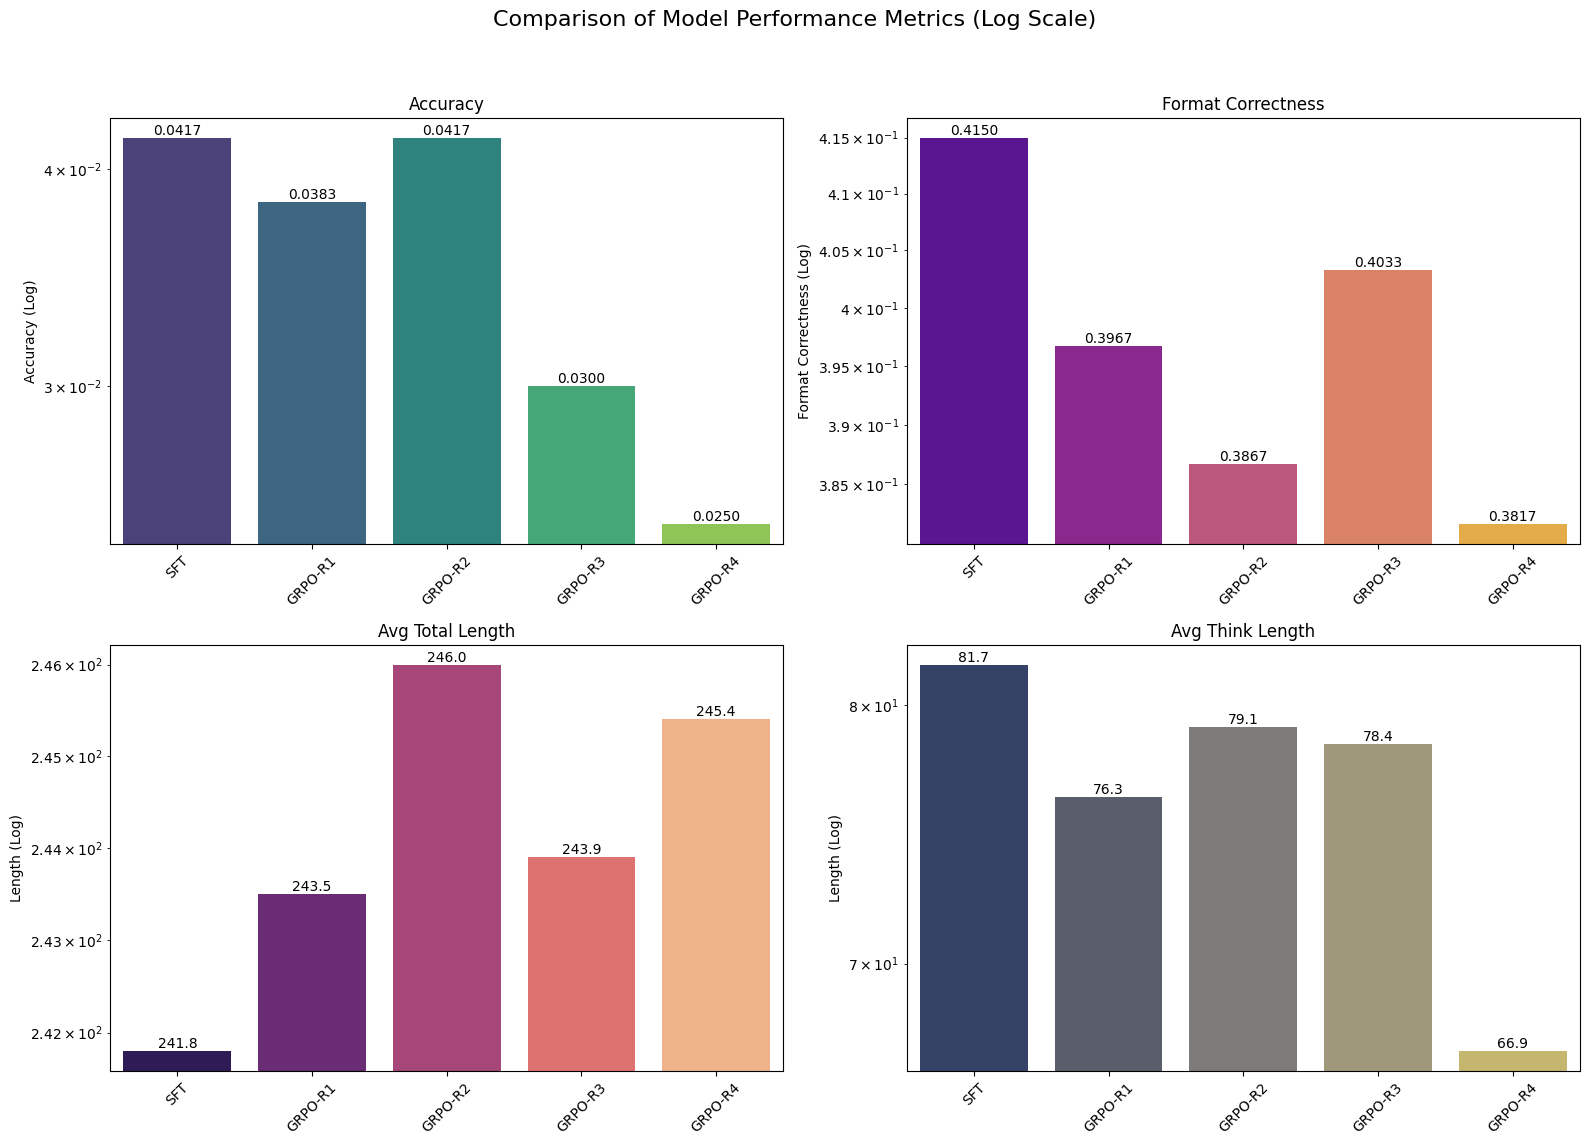

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame.from_dict(all_results, orient='index')
df_results.index.name = 'Model'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparison of Model Performance Metrics (Log Scale)', fontsize=16)


def format_log_axis(ax, title, ylabel, data_col, palette, format_str):
    sns.barplot(x=df_results.index, y=data_col, data=df_results, ax=ax, palette=palette, hue=df_results.index, legend=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale('log')

    for p in ax.patches:
        val = p.get_height()
        if val > 0:
            ax.annotate(f'{val:{format_str}}',
                        (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', xytext=(0, 0),
                        textcoords='offset points')


format_log_axis(axes[0, 0], 'Accuracy', 'Accuracy (Log)', 'accuracy', 'viridis', '.4f')

format_log_axis(axes[0, 1], 'Format Correctness', 'Format Correctness (Log)', 'format_correct', 'plasma', '.4f')

format_log_axis(axes[1, 0], 'Avg Total Length', 'Length (Log)', 'avg_total_length', 'magma', '.1f')

format_log_axis(axes[1, 1], 'Avg Think Length', 'Length (Log)', 'avg_think_length', 'cividis', '.1f')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()